In [1]:
#get necessary libraries
!pip install "nilearn>=0.9.0"
!pip install brainspace
!pip install panel
!pip list

Package                       Version
----------------------------- ---------
absl-py                       2.1.0
aiobotocore                   2.5.0
aiofiles                      22.1.0
aiohttp                       3.8.3
aioitertools                  0.7.1
aiosignal                     1.2.0
aiosqlite                     0.18.0
alabaster                     0.7.12
altair                        5.2.0
anaconda-anon-usage           0.4.4
anaconda-catalogs             0.2.0
anaconda-client               1.12.0
anaconda-cloud-auth           0.4.1
anaconda-navigator            2.5.4
anaconda-project              0.11.1
annotated-types               0.6.0
anyio                         3.5.0
appdirs                       1.4.4
applaunchservices             0.3.0
appnope                       0.1.2
appscript                     1.1.2
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
arrow                         1.2.3
astroid                       2.14.2
astropy       

In [4]:
# if you want to get data into BIDS
#docker run -ti --rm \
 # -v <local_BIDS_data_dir>:/data:ro \
  #-v <local_output_dir>:/out poldracklab/fmriprep:latest \
  #--output-spaces fsaverage5 \
  #--fs-license-file license.txt \
  #/data /out participant

In [2]:
# download the packages
from brainspace.datasets import load_conte69
from brainspace.datasets import load_group_fc, load_parcellation
import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets
from brainspace.utils.parcellation import reduce_by_labels
from nilearn.connectome import ConnectivityMeasure

from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
from brainspace.gradient import GradientMaps



In [3]:
# get the surface
surf_lh, surf_rh = load_conte69()
print(type(surf_rh))
print(surf_lh.n_points)

# plot the surface
#plot_hemispheres(surf_lh, surf_rh, size=(800, 200))

# load an example matrix
labeling = load_parcellation('schaefer', scale=400, join=True)
print(labeling.shape)
print(type(labeling))
m = load_group_fc('schaefer', scale=400)
print(m.shape)

# build gradient using diffusion map and normalized angle and then fit to data
gm = GradientMaps(n_components=2, approach='dm', kernel='normalized_angle')
gm.fit(m)
print(gm.gradients_.shape)

# map the gradient and plot on cortical surface
grad = map_to_labels(gm.gradients_[:, 0], labeling, mask=labeling != 0, fill=np.nan)
print(grad.shape)
#display(plot_hemispheres(surf_lh, surf_rh, array_name=grad, size=(800, 200)))

<class 'brainspace.vtk_interface.wrappers.data_object.BSPolyData'>
32492
(64984,)
<class 'numpy.ndarray'>
(400, 400)
(400, 2)
(64984,)


In [13]:
import nibabel as nib
import numpy as np
# get out the time series - if you want to preprocess here then separate raw data by left and right hemispheres

#filename = 'filename.{}.mgz' # where {} will be replaced with 'lh' and 'rh'
#timeseries = [None] * 2
#for i, h in enumerate(['lh', 'rh']):
 #   timeseries[i] = nib.load(filename.format(h)).get_fdata().squeeze()
#timeseries = np.vstack(timeseries)

# working example of getting timeseries
from brainspace.datasets import fetch_timeseries_preprocessing
timeseries = fetch_timeseries_preprocessing()

print(timeseries.shape)

(20484, 652)


In [36]:
from nilearn.interfaces.fmriprep import load_confounds_strategy
#confounds_out = load_confounds_strategy("path/to/fmriprep/output/sub-<subject>_task-<task>_space-<space>_desc-preproc_bold.nii.gz", denoise_strategy='simple')

# working example of removing confounds
from brainspace.datasets import load_confounds_preprocessing
confounds_out = load_confounds_preprocessing()
print(confounds_out)

# confound regression
from nilearn import signal
clean_ts = signal.clean(timeseries.T, confounds=confounds_out).T

[[-0.04489291  0.02242501 -0.06483001 ...  1.         -1.
   1.        ]
 [-0.01685083  0.02101512  0.0728119  ...  1.         -0.9969278
   0.99079757]
 [-0.05601484  0.04663152 -0.02977088 ...  1.         -0.99385561
   0.98162345]
 ...
 [-0.01182186 -0.03062136  0.02775342 ...  1.          0.99385561
   0.98162345]
 [ 0.00536774 -0.02590527 -0.02545823 ...  1.          0.9969278
   0.99079757]
 [ 0.05711278  0.0030458  -0.01673093 ...  1.          1.
   1.        ]]


/var/folders/jf/53xccyzd5ql0h1292hjgh45m0000gn/T/ipykernel_11267/3218415386.py:11: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_ts = signal.clean(timeseries.T, confounds=confounds_out).T


In [19]:
# extract cleaned timeseries 
import numpy as np
from nilearn import datasets
from brainspace.utils.parcellation import reduce_by_labels

# Fetch surface atlas (use Allen mouse atlas) - atlas must have labels
atlas = datasets.fetch_atlas_surf_destrieux()
print(atlas)

# Remove non-cortex regions (or any regions to mask)
regions = atlas['labels'].copy()
masked_regions = [b'Medial_wall', b'Unknown']
masked_labels = [regions.index(r) for r in masked_regions]
for r in masked_regions:
    regions.remove(r)

# Build Destrieux parcellation and mask - make custom parcellation file
labeling = np.concatenate([atlas['map_left'], atlas['map_right']])
print(labeling.shape)
mask = ~np.isin(labeling, masked_labels)

# Distinct labels for left and right hemispheres
lab_lh = atlas['map_left']
labeling[lab_lh.size:] += lab_lh.max() + 1

# extract mean timeseries for each label
seed_ts = reduce_by_labels(clean_ts[mask], labeling[mask], axis=1, red_op='mean')


{'labels': [b'Unknown', b'G_and_S_frontomargin', b'G_and_S_occipital_inf', b'G_and_S_paracentral', b'G_and_S_subcentral', b'G_and_S_transv_frontopol', b'G_and_S_cingul-Ant', b'G_and_S_cingul-Mid-Ant', b'G_and_S_cingul-Mid-Post', b'G_cingul-Post-dorsal', b'G_cingul-Post-ventral', b'G_cuneus', b'G_front_inf-Opercular', b'G_front_inf-Orbital', b'G_front_inf-Triangul', b'G_front_middle', b'G_front_sup', b'G_Ins_lg_and_S_cent_ins', b'G_insular_short', b'G_occipital_middle', b'G_occipital_sup', b'G_oc-temp_lat-fusifor', b'G_oc-temp_med-Lingual', b'G_oc-temp_med-Parahip', b'G_orbital', b'G_pariet_inf-Angular', b'G_pariet_inf-Supramar', b'G_parietal_sup', b'G_postcentral', b'G_precentral', b'G_precuneus', b'G_rectus', b'G_subcallosal', b'G_temp_sup-G_T_transv', b'G_temp_sup-Lateral', b'G_temp_sup-Plan_polar', b'G_temp_sup-Plan_tempo', b'G_temporal_inf', b'G_temporal_middle', b'Lat_Fis-ant-Horizont', b'Lat_Fis-ant-Vertical', b'Lat_Fis-post', b'Medial_wall', b'Pole_occipital', b'Pole_temporal', 

/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/nilearn/connectome/connectivity_matrices.py:509: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  covariances_std = [


(400, 400)
(64984,)


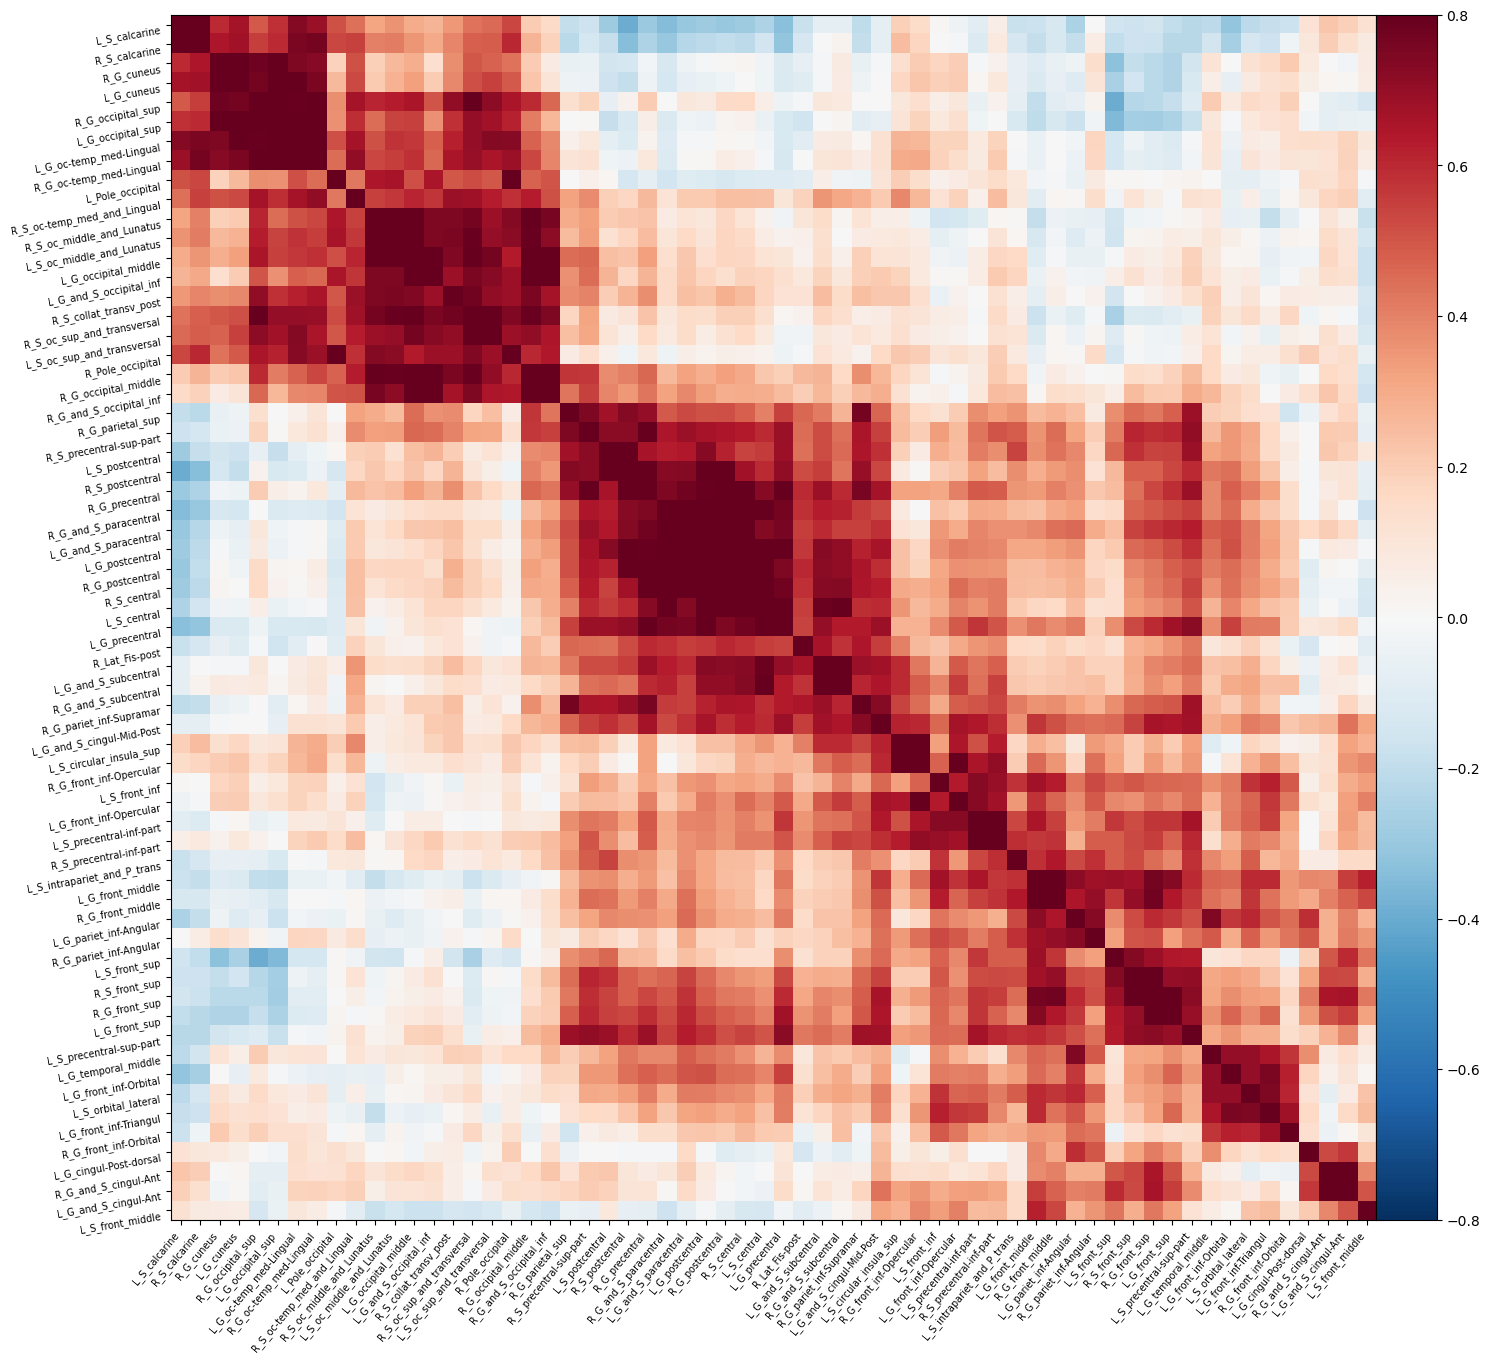

In [10]:
# calculate fc matrix 
from nilearn.connectome import ConnectivityMeasure

correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([seed_ts.T])[0]

# plot fc matrix
from nilearn import plotting

# Reduce matrix size, only for visualization purposes
mat_mask = np.where(np.std(correlation_matrix, axis=1) > 0.2)[0]
c = correlation_matrix[mat_mask][:, mat_mask]

# Create corresponding region names
regions_list = ['%s_%s' % (h, r.decode()) for h in ['L', 'R'] for r in regions]
masked_regions = [regions_list[i] for i in mat_mask]


corr_plot = plotting.plot_matrix(c, figure=(15, 15), labels=masked_regions, vmax=0.8, vmin=-0.8, reorder=True)


# load example con matrixes and parcellation
conn_matrix = load_group_fc('schaefer', scale=400)
labeling = load_parcellation('schaefer', scale=400, join=True)

print(conn_matrix.shape)
print(labeling.shape)
mask = labeling != 0

# and load the conte69 hemisphere surfaces
surf_lh, surf_rh = load_conte69()

In [35]:
from brainspace.gradient import GradientMaps


# basic
gm = GradientMaps(n_components=10, random_state=0)
gm.fit(correlation_matrix)


# customize gradient analysis
kernels = ['pearson', 'spearman', 'normalized_angle']

gradients_kernel = [None] * len(kernels)
embeddings = ['pca', 'le', 'dm']
gradients_embedding = [None] * len(embeddings)

# if you want to use different kernels for getting gradient or different dimensionality reduction (approach - PCA, laplacian eigenmaps, diffusion mapping)
for i, k in enumerate(kernels):
    gm = GradientMaps(kernel=k, approach='dm', random_state=0) # use approach = emb and enumerate over embeddings if changing dimensionality
    gm.fit(conn_matrix)

    gradients_kernel[i] = map_to_labels(gm.gradients_[:, i], labeling, mask=mask, fill=np.nan)
    print(gradients_kernel[i])


label_text = ['Pearson', 'Spearman', 'Normalized\nAngle']
#plot_hemispheres(surf_lh, surf_rh, array_name=gradients_kernel, size=(1200, 600), cmap='viridis_r', color_bar=True, label_text=label_text, zoom=1.45)

/Users/rachelfox/opt/anaconda3/lib/python3.9/site-packages/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


[-15.77665324  16.44757972  15.53068447 ...  -9.39558197  -9.39558197
  -9.39558197]
[-5.36684824 -6.62156107 -6.29420571 ... -1.01089505 -1.01089505
 -1.01089505]
[-0.06421125 -0.02976587 -0.03676418 ...  0.06540111  0.06540111
  0.06540111]


: 

(400,)
[196  67  47 ... 339 339 339]
0.1327508727364674


array([-0.12516273,  0.03916495,  0.04332321, ..., -0.06294277,
       -0.06294277, -0.06294277])

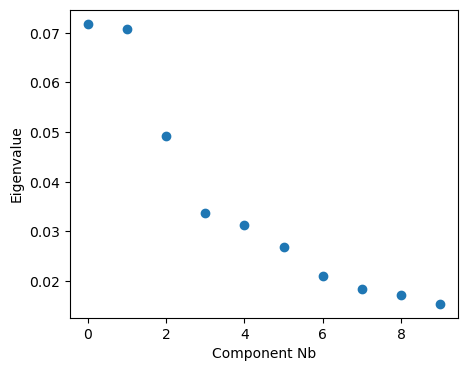

In [31]:
# visualize results
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels


# Map gradients to original parcels
# it seems like the labels are numbers and the gradient is then mapped to that
# it seems like what other papers did is they used the parcellation numbers (that in theory are found to be mapped to regions such as DMN, limbic area, etc and then the corresponding gradient score can be calculated for those areas) and these parcellation numbers can be matched to the yeo 17 areas 
# can compare gradient scores in principal gradients between groups and then find t score from there
# ex https://www.ncbi.nlm.nih.gov/pmc/articles/pmid/36496508/

grad = [None] * gm.gradients_.T.shape[0]
for i, g in enumerate(gm.gradients_.T):
    #print(g.shape) #400 which is the shape of the gradient
    grad[i] = map_to_labels(g, labeling, mask=mask, fill=np.nan)
    #print(grad[i].shape) #64984 (same as labels)
    

print(gm.gradients_[:, 0].shape)
print(labeling)
print(max(grad[0]))
# Load fsaverage5 surfaces
surf_lh, surf_rh = load_fsa5()

#plot_hemispheres(surf_lh, surf_rh, array_name=grad, size=(1200, 400), cmap='viridis_r',color_bar=True, label_text=['Grad1', 'Grad2'], zoom=1.5)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm.lambdas_.size), gm.lambdas_)
ax.set_xlabel('Component Nb')
ax.set_ylabel('Eigenvalue')

# the gradient outputted is a list of each of the gradient components (networks?) where the number is the value corresponding to a gradient and parts not in the brain are nan and the number of points total (combined R and L hemisphere)
grad[0] # is a lot of numbers
#plt.show()

In [110]:
# align gradients between two groups
conn_matrix = load_group_fc('schaefer', scale=400)
labeling = load_parcellation('schaefer', scale=400, join=True)
mask = labeling != 0
surf_lh, surf_rh = load_conte69()

conn_matrix2 = load_group_fc('schaefer', scale=400, group='holdout')
gp = GradientMaps(kernel='normalized_angle', alignment='procrustes', approach="dm", n_components=10)
# can use the principal gradient to represent most of the explained variance
#gj = GradientMaps(kernel='cosine', alignment='joint')

gp.fit([conn_matrix, conn_matrix2])
#gj.fit([conn_matrix, conn_matrix2])

#print(gp.aligned_[0][:,0])
#plot_hemispheres(surf_lh, surf_rh, gp.aligned_[0][:,0])

gradients_procrustes = [None] * 2
for i in range(2):
    gradients_procrustes[i] = map_to_labels(gp.aligned_[i][:, 0], labeling, mask=mask,
                                            fill=np.nan)

label_text = ['Procrustes\nGroup 1', 'Procrustes\nGroup 2']

print(labeling)
#plot_hemispheres(surf_lh, surf_rh, array_name=gradients_procrustes, size=(1200, 400), cmap='viridis_r', color_bar=True, label_text=label_text, zoom=1.5)
# can also align to a template gradient

[196  67  47 ... 339 339 339]


In [4]:
# CIMT Data
import os
#folder_path = '/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/07d'
folder_path = '07d'

# List to store dataframes
dfs_SHM = []
dfs_CCI = []

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if 'SHM' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_SHM.append(df)
    elif 'CCI' in file_name and file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        dfs_CCI.append(df)

# print(len(dfs_SHM))
# print(len(dfs_CCI))
mean_df_SHM = pd.concat(dfs_SHM).groupby(level=0).mean()
mean_df_CCI = pd.concat(dfs_CCI).groupby(level=0).mean()

print(mean_df_SHM)
print(mean_df_CCI)

           0           1           2           3          4          5    \
0    99.843885   99.921817  100.171083   99.895301  98.219479  99.813324   
1    99.828746   99.908396  100.152426   99.908427  98.278936  99.823760   
2    99.826254   99.881386  100.111314   99.931550  98.318455  99.842364   
3    99.834629   99.842865  100.051096   99.955009  98.326958  99.868441   
4    99.845012   99.801542   99.981161   99.960235  98.308832  99.895268   
..         ...         ...         ...         ...        ...        ...   
245  99.914581  100.254782  100.014257  100.173750  98.170343  99.840988   
246  99.904489  100.256122  100.055575  100.166607  98.151082  99.867770   
247  99.887036  100.259094  100.062765  100.149055  98.133362  99.904886   
248  99.868293  100.272069  100.021469  100.131014  98.118196  99.941127   
249  99.852157  100.290833   99.939100  100.116565  98.108269  99.971723   

           6          7          8          9    ...         114        115  \
0    99.

In [5]:
# LEIDA EXAMPLE
# input Leida timeseries
import pandas as pd
from brainspace.utils.parcellation import reduce_by_labels


#example_ts = np.loadtxt('/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/07d/CCI_none_07d_002.nii.csv', delimiter=',').T
#print(example_ts)
mean_SHM_ts = (mean_df_SHM.T).values
mean_CCI_ts = (mean_df_CCI.T).values
# confound regression here

#parcellation_img = nib.load('/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/01_study_specific_atlas_relabel.nii')
parcellation_img = nib.load('01_study_specific_atlas_relabel.nii')
parcellation_data = parcellation_img.get_fdata()
print(parcellation_data.shape)


#df = pd.read_csv('/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/rois_labels.txt', header=None, delimiter='\s+')
df = pd.read_csv('rois_labels.txt', header=None, delimiter='\s+')
print(df)
labels = df[1].to_numpy()[:124]

print(mean_SHM_ts.shape)
print(labels.shape)
seed_ts_SHM = reduce_by_labels(mean_SHM_ts, labels, axis=1, red_op='mean')
seed_ts_CCI = reduce_by_labels(mean_CCI_ts, labels, axis=1, red_op='mean')
print(seed_ts_SHM)
print(seed_ts_SHM.shape)

(96, 96, 25)
       0                          1
0      1              Acumbens_left
1      2                   AID_left
2      3                   AIP_left
3      4                   AIV_left
4      5              Amygdala_left
..   ...                        ...
119  120                  SaP_right
120  121  Superior_Colliculus_right
121  122           Thalamus_A_right
122  123           Thalamus_P_right
123  124               VP_mfb_right

[124 rows x 2 columns]
(124, 250)
(124,)
[[ 99.92181684  99.90839587  99.88138594 ... 100.25909375 100.27206947
  100.29083287]
 [ 99.16211783  99.11628746  99.05990436 ...  99.32570603  99.40939758
   99.46570304]
 [100.17108324 100.1524257  100.11131413 ... 100.06276486 100.02146871
   99.93910036]
 ...
 [ 99.85720341  99.83991659  99.8424522  ...  99.76382645  99.71458362
   99.70155313]
 [ 99.71995223  99.73209601  99.74619068 ...  99.53742818  99.47018338
   99.42409966]
 [ 99.73204093  99.73341098  99.7365869  ...  99.71477449  99.70827152
  

In [6]:
print(parcellation_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (96, 96, 25)
affine:
[[-3.12500000e+00  0.00000000e+00  0.00000000e+00  1.46875000e+02]
 [ 0.00000000e+00  6.93889390e-16  7.50000000e+00 -9.37500000e+01]
 [ 0.00000000e+00  3.12500000e+00  1.66533454e-15 -1.50000000e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b'6.0.5.1:57b01774'
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [ 3 96 96 25  1  1  1  1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint32
bitpix          : 32
slice_start     : 0
pixdim          : [1.    3.125 3.125 7.5   0.    0.    0.    0.   ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal

In [10]:
yeo = nib.load('FSL_MNI152_FreeSurferConformed_1mm.nii')
print(yeo)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (256, 256, 256)
affine:
[[  -1.    0.    0.  127.]
 [   0.    0.    1. -145.]
 [   0.   -1.    0.  147.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 256 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [-1.  1.  1.  1.  1.  1.  1.  1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FreeSurfer Feb 19 2010'
aux_file        : b''
qform_code      : s

In [9]:
import scipy.io
mat = scipy.io.loadmat('HCP_1029sub_400Parcels_Kong2022_gMSHBM.mat')
print(mat['lh_labels_all'])

[[  4   4   4 ...  19   4  19]
 [153 153 153 ... 153 153 153]
 [165 166 166 ... 166 166 166]
 ...
 [ 63  63  63 ...  63  63  74]
 [ 63  63  63 ...  74  27  74]
 [ 63  63  63 ...  63  63  74]]


In [25]:
# Fetch surface atlas (use Allen mouse atlas) - atlas must have labels

atlas = datasets.fetch_atlas_surf_destrieux()

print(type(atlas))


# Remove non-cortex regions (or any regions to mask)
regions = atlas['labels'].copy()
masked_regions = [b'Medial_wall', b'Unknown']
masked_labels = [regions.index(r) for r in masked_regions]
for r in masked_regions:
    regions.remove(r)

# Build Destrieux parcellation and mask - make custom parcellation file
labeling = np.concatenate([atlas['map_left'], atlas['map_right']])
print(type(labels))
mask = ~np.isin(labeling, masked_labels)

# Distinct labels for left and right hemispheres
lab_lh = atlas['map_left']
labeling[lab_lh.size:] += lab_lh.max() + 1

# extract mean timeseries for each label
#print(clean_ts.shape)
#print(type(labeling))
#print(labeling.shape)
#seed_ts = reduce_by_labels(clean_ts[mask], labeling[mask], axis=1, red_op='mean')


<class 'sklearn.utils.Bunch'>
<class 'numpy.ndarray'>


[  0   1   2   3   4   5   6   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  26  27  28  29  30  31  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  50  51  52  53  54  55  56  57  58
  59  60  62  64  66  67  70  71  72  73  74  76  77  78  79  80  81  83
  84  87  88  91  92  94  95  96  97  98 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 116 117 118 119 120 121]
(103, 103)
(124, 124)


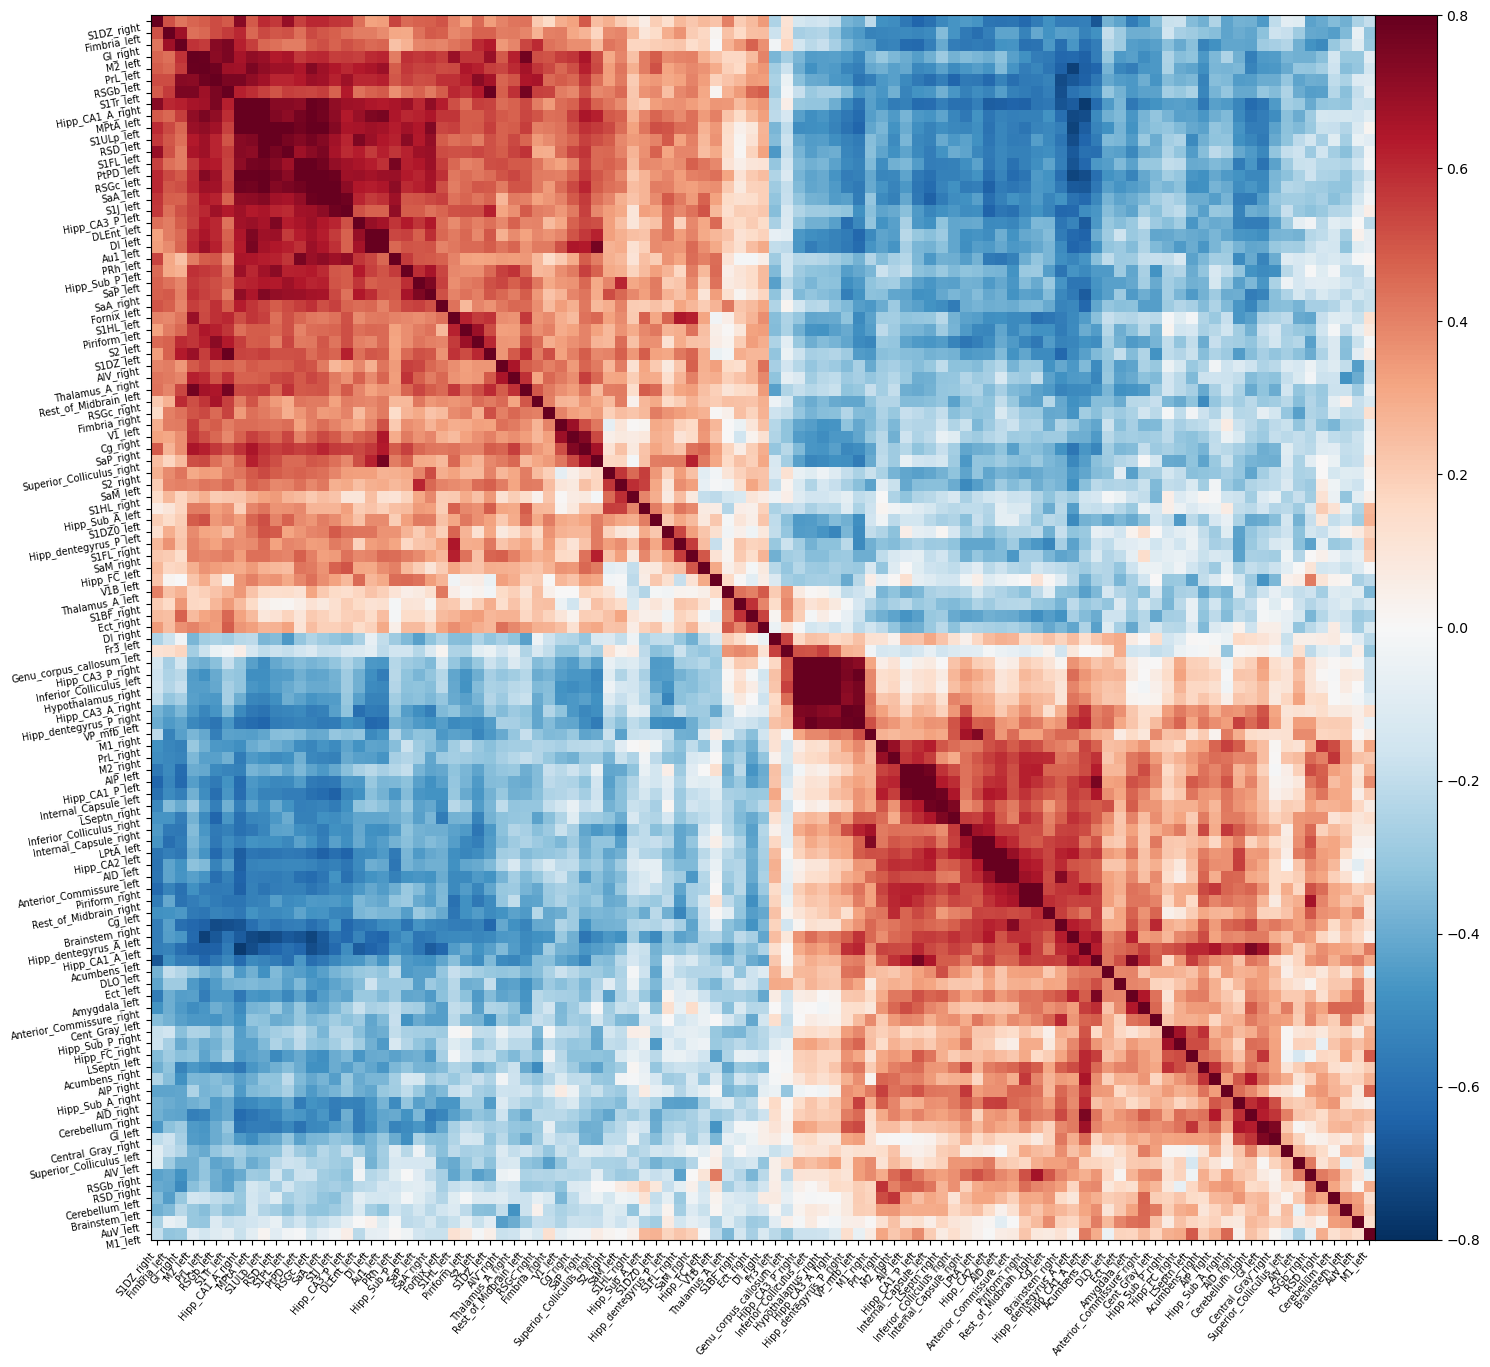

In [5]:
from nilearn.connectome import ConnectivityMeasure

correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix_SHM = correlation_measure.fit_transform([seed_ts_SHM.T])[0]
correlation_matrix_CCI = correlation_measure.fit_transform([seed_ts_CCI.T])[0]

from nilearn import plotting

# Reduce matrix size, only for visualization purposes
mat_mask = np.where(np.std(correlation_matrix_CCI, axis=1) > 0.2)[0]
print(mat_mask)
c = correlation_matrix_CCI[mat_mask][:, mat_mask]
print(c.shape)
print(correlation_matrix_CCI.shape)

# Create corresponding region names
regions_list = labels
#regions_list = ['%s_%s' % (h, r.decode()) for h in ['L', 'R'] for r in labels]
masked_regions = [regions_list[i] for i in mat_mask]


corr_plot = plotting.plot_matrix(c, figure=(15, 15), labels=masked_regions,
                                 vmax=0.8, vmin=-0.8, reorder=True)

GradientMaps(kernel='pearson', random_state=0)
GradientMaps(kernel='pearson', random_state=0)
(124,)


Text(0, 0.5, 'Eigenvalue')

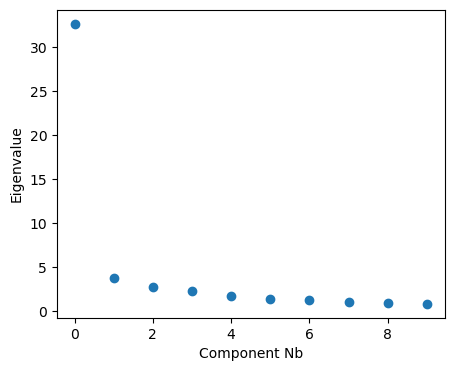

In [6]:
from brainspace.gradient import GradientMaps
from brainspace.datasets import load_fsa5
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels

gm_SHM = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_SHM.fit(correlation_matrix_SHM)
print(gm_SHM)

gm_CCI = GradientMaps(n_components=10, kernel='pearson', approach='dm', random_state=0)
gm_CCI.fit(correlation_matrix_CCI)
print(gm_CCI)

grad_SHM = [None] * gm_SHM.gradients_.T.shape[0]
grad_CCI = [None] * gm_CCI.gradients_.T.shape[0]
for i, g in enumerate(gm_SHM.gradients_.T):
    grad_SHM[i] = map_to_labels(g, labels, fill=np.nan)
for i, g in enumerate(gm_CCI.gradients_.T):
    #print(g.shape) #400 which is the shape of the gradient
    grad_CCI[i] = map_to_labels(g, labels, fill=np.nan)
    #print(grad[i].shape) #64984 (same as labels)
    

print(gm_CCI.gradients_[:, 0].shape)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm_CCI.lambdas_.size), gm_CCI.lambdas_)
ax.set_xlabel('Component Nb')
ax.set_ylabel('Eigenvalue')

#print(grad_CCI)

In [7]:
print(type(gm_CCI.gradients_))

<class 'numpy.ndarray'>


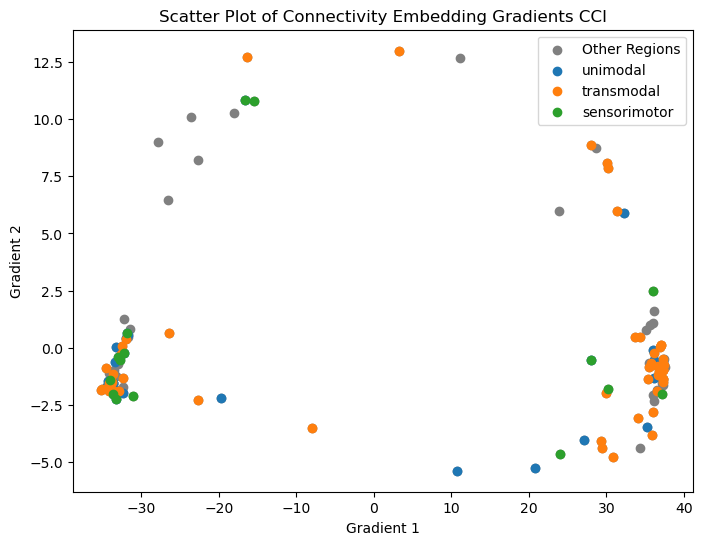

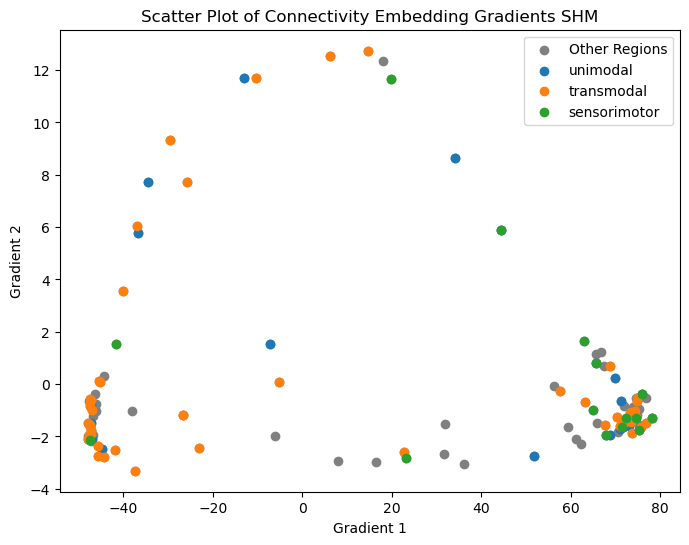

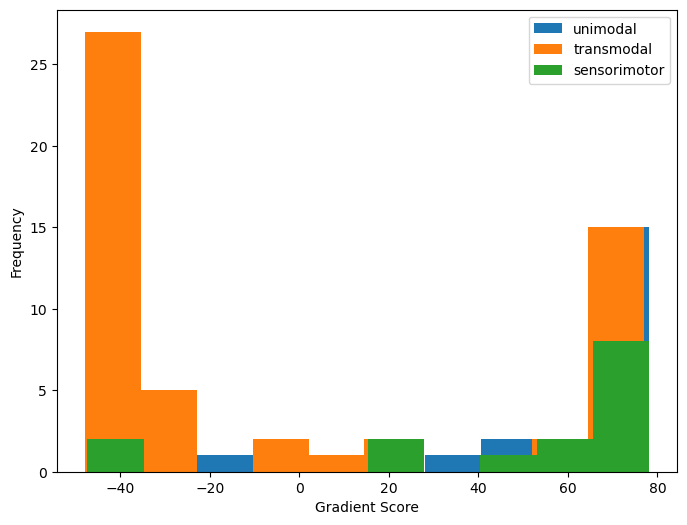

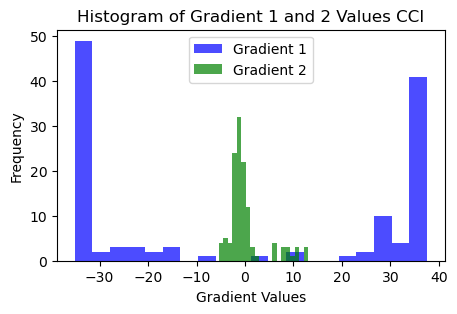

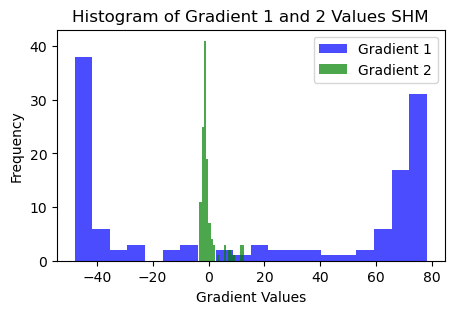

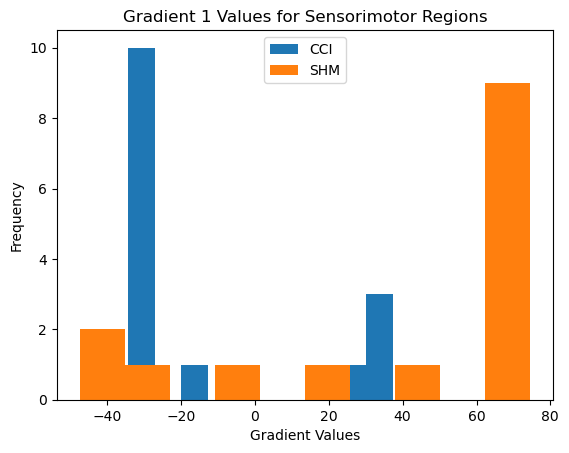

In [8]:
# gradient figures
#print(grad_CCI[0])
gradient1CCI = gm_CCI.gradients_[:, 0] # extract 1st component
# print(gradient1CCI.tolist())
gradient2CCI = gm_CCI.gradients_[:, 1] # extract 2nd component

gradient1SHM = gm_SHM.gradients_[:, 0] # extract 1st component
gradient2SHM = gm_SHM.gradients_[:, 1] # extract 2nd component

region_categories = {
   #yeo networks are visual, somatomotor, dosralattention, salientventralattention, control, limbic, default - figure out which of our ROIs are involved in each of these
   #unimodal regions primarily process and integrate info within a single sensory or motor modality
   #transmodal regions are involved in integrating and processing info across multiple sensory or cognitive modalities
   #sensorimotor regions are involved in both sensory processing and motor control; integrate sensory info w/ motor commands to guide voluntary movements and behaviors
   'unimodal': [67, 68, 69, 70, 71, 72, 73, 74, 7, 8, 9, 50, 51, 52, 53, 54, 55, 56, 57, 58, 112, 113, 114, 115, 116, 117],
   'transmodal': [6, 77, 12, 80, 13, 81, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 37, 86, 38, 103, 43, 106, 46, 79, 108, 109, 110, 111, 47, 48, 49, 62, 106, 63, 121, 64, 106, 124],
   'sensorimotor': [39, 40, 50, 54, 58, 65, 66, 104, 105, 112, 114, 115, 117, 122, 123]
}
# the sensorimotor regions are at each corner of the scatter plot which indicates less of a distinction in connectivity between groups
# if the gradient score is large, then that means that region is important 

plt.figure(figsize=(8, 6))
plt.scatter(gradient1CCI, gradient2CCI, c='gray', label='Other Regions')

for category, indices in region_categories.items():
    #print(np.array(indices)-1)
    adjusted_indices = np.array(indices)-1
    plt.scatter(gradient1CCI[adjusted_indices], gradient2CCI[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients CCI')
plt.legend()


plt.figure(figsize=(8, 6))
plt.scatter(gradient1SHM, gradient2SHM, c='gray', label='Other Regions')

for category, indices in region_categories.items():
    adjusted_indices = np.array(indices)-1
    plt.scatter(gradient1SHM[adjusted_indices], gradient2SHM[adjusted_indices], label=category)
plt.xlabel('Gradient 1')
plt.ylabel('Gradient 2')
plt.title('Scatter Plot of Connectivity Embedding Gradients SHM')
plt.legend()

plt.figure(figsize=(8, 6))
for category, indices in region_categories.items():
    adjusted_indices = np.array(indices)-1
    plt.hist(gradient1SHM[adjusted_indices], label=category)
plt.xlabel('Gradient Score')
plt.ylabel('Frequency')
plt.legend()

plt.figure(figsize=(5, 3))
plt.hist(gradient1CCI, bins=20, color='b', alpha=0.7, label='Gradient 1')
plt.hist(gradient2CCI, bins=20, color='g', alpha=0.7, label='Gradient 2')
plt.xlabel('Gradient Values')
plt.ylabel('Frequency')
plt.title('Histogram of Gradient 1 and 2 Values CCI')
plt.legend()

plt.figure(figsize=(5, 3))
plt.hist(gradient1SHM, bins=20, color='b', alpha=0.7, label='Gradient 1')
plt.hist(gradient2SHM, bins=20, color='g', alpha=0.7, label='Gradient 2')
plt.xlabel('Gradient Values')
plt.ylabel('Frequency')
plt.title('Histogram of Gradient 1 and 2 Values SHM')
plt.legend()
# gradient 1 for both CCI and SHM split between two high magnitude values while gradient 2 is around 0 and separates something
# There are intrinsic differences between the gradients for CCI and Sham (which were calculated separately)

plt.figure()
sensorimotorindices = [38, 39, 49, 53, 57, 64, 65, 103, 104, 111, 113, 114, 116, 121, 122]
plt.hist(gradient1CCI[indices], label='CCI')
plt.hist(gradient1SHM[indices], label='SHM')
plt.xlabel('Gradient Values')
plt.ylabel('Frequency')
plt.title('Gradient 1 Values for Sensorimotor Regions')
plt.legend()
# in the sensorimotor region CCI mainly has more negative principal gradient scores and sham has more positive principal scores (each at high magnitude)

In [23]:
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(mean_df_CCI)

ica = FastICA(n_components=7, random_state=0)
mean_df_CCI_transformed = ica.fit_transform(scaled_data)

# Get the mixing matrix (unmixing matrix) which represents the loadings of each ROI on each independent component
unmixing_matrix = ica.mixing_
print(unmixing_matrix[:, 0].shape)

# Create a DataFrame to display the unmixing matrix
unmixing_matrix_df = pd.DataFrame(unmixing_matrix, index=mean_df_CCI.columns, columns=[f'IC{i+1}' for i in range(unmixing_matrix.shape[1])])
                                                                                       
# Filter ROIs based on the top 10% loading value for each IC
significant_rois = {}
for ic in range(unmixing_matrix_df.shape[1]):
    # Compute the threshold based on the top 10% loading value for each IC
    threshold = np.percentile(unmixing_matrix_df[f'IC{ic+1}'].abs(), 85)
    # Select ROIs with loading values above the threshold
    significant_rois[f'IC{ic+1}'] = unmixing_matrix_df.index[unmixing_matrix_df[f'IC{ic+1}'].abs() > threshold].tolist()
# df = pd.read_csv(‘/Users/rachelfox/dFC_Toolboxes/Leida/CSVs_with_regions_stim_pattern_CIMT/rois_labels.txt’, header=None, delimiter=‘\s+’)
df = pd.read_csv('rois_labels.txt', header=None, delimiter='\s+')
# Display the significant ROIs for each independent component
for ic, rois in significant_rois.items():
    print(f"Significant ROIs for {ic}:")
    print(rois)
    print(df.iloc[rois, 1])


(124,)
Significant ROIs for IC1:
[11, 17, 23, 30, 31, 34, 63, 66, 74, 76, 82, 84, 85, 86, 89, 90, 91, 93, 96]
11               Cerebellum_left
17                  Fimbria_left
23               Hipp_CA1_P_left
30               Hipp_Sub_A_left
31               Hipp_Sub_P_left
34      Inferior_Colliculus_left
63                      TeA_left
66                      V1B_left
74                     AIV_right
76     Anterior_Commissure_right
82                   DLEnt_right
84                 Fimbria_right
85                  Fornix_right
86    Genu_corpus_callosum_right
89              Hipp_CA1_P_right
90                Hipp_CA2_right
91              Hipp_CA3_A_right
93       Hipp_dentegyrus_A_right
96              Hipp_Sub_A_right
Name: 1, dtype: object
Significant ROIs for IC2:
[12, 19, 20, 33, 35, 36, 43, 48, 50, 54, 84, 89, 101, 106, 108, 111, 116, 119, 122]
12                       Cg_left
19                      Fr3_left
20     Genu_corpus_callosum_left
33                       IL_lef

/Users/fei/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [5]:
from brainspace.mesh import mesh_io as mio
import nibabel as nib

# pull out the surface
# in matlab to get to .nv format -- BrainNet_GenSurface('pathtosurf/left_hemisphere.nii', 'pathtosurf/left_hemisphere.nv'), then use surf_ice to get to .gii format

# the surfaces must be .gii or .vtk format to work in brainspace libraries 
# -- there is possible issue in conversion from the nii file to the 1d array format needed to map to the gifti surface
left_s = mio.read_surface('/Users/rachelfox/Downloads/recimtatlaslvsr/left_hemisphere.gii')
right_s = mio.read_surface('/Users/rachelfox/Downloads/recimtatlaslvsr/right_hemisphere.gii')
print(type(left_s)) # <class 'brainspace.vtk_interface.wrappers.data_object.BSPolyData'>
print(left_s.n_points) # 66467
print(right_s.n_points) # 59327

# this is showing the nifti file is corret shape (same as the nifti file for the labels)
surf_as_nifti = '/Users/rachelfox/Downloads/recimtatlaslvsr/left_hemisphere.nii'
surf_img = nib.load(surf_as_nifti)
img_nifti = surf_img.get_fdata()
print(img_nifti.shape) # (136, 102, 180)

# the labels have the same 3d shape but to get these labels into a 1d array to map to the surface the dimensions are incorrect (should be same as left_s.n_points value)
# Load the NIfTI file
atlas_file_r = '/Users/rachelfox/Downloads/recimtatlaslvsr/zzlabels_right_add199.nii'
atlas_img_r = nib.load(atlas_file_r)
atlas_file_l = '/Users/rachelfox/Downloads/recimtatlaslvsr/zzlabels_left_add199.nii'
atlas_img_l = nib.load(atlas_file_l)

atlas_data_r = atlas_img_r.get_fdata()
atlas_data_l = atlas_img_l.get_fdata()

label_table_file = '/Users/rachelfox/dFC_Toolboxes/Leida/rois_labels.txt'
with open(label_table_file, 'r') as f:
    label_table = {}
    for line in f:
        index, label = line.strip().split('\t')
        label_table[int(index)] = label

labeling_array_r = np.empty_like(atlas_data_r, dtype='U100')
labeling_array_l = np.empty_like(atlas_data_l, dtype='U100')

# Map each numerical index to its corresponding label
for index, label in label_table.items():
    labeling_array_r[atlas_data_r == index] = label
    labeling_array_l[atlas_data_l == index] = label

labeling_array_r = np.array(labeling_array_r)
labeling_array_l = np.array(labeling_array_l)

print(labeling_array_r.shape) # (136, 102, 180)
print(labeling_array_r.flatten().shape) # (2496960,)
print(labeling_array_l.shape) # (136, 102, 180)
print(labeling_array_l.flatten().shape) # (2496960,)

labeling_array = np.concatenate([labeling_array_l, labeling_array_r]) 
print(labeling_array.shape) # (272, 102, 180)

# this function does work to just plot the surface
#plot_hemispheres(left_s, right_s, size=(800, 200)) 

# but this function will not work to add the labels: error ValueError: Cannot broadcast 'array_name' with shape (272,) to shape (1, 4)
plot_hemispheres(left_s, right_s, array_name=labeling_array, size=(1200, 200), cmap='tab20', zoom=1.85)




<class 'brainspace.vtk_interface.wrappers.data_object.BSPolyData'>
66467
59327
(136, 102, 180)
(136, 102, 180)
(2496960,)
(136, 102, 180)
(2496960,)
(272, 102, 180)


ValueError: Cannot broadcast 'array_name' with shape (272,) to shape (1, 4)

In [71]:
# the surfaces must be .gii or .vtk format to work in brainspace libraries 
# -- there is possible issue in conversion from the nii file to the 1d array format needed to map to the gifti surface
left_s = mio.read_surface('/Users/rachelfox/Downloads/recimtatlaslvsr/left_hemisphere.gii')
right_s = mio.read_surface('/Users/rachelfox/Downloads/recimtatlaslvsr/right_hemisphere.gii')

print(type(left_s))
print(right_s.n_points)
print(left_s.n_points)

# this is showing the nifti file is corret shape (same as the nifti file for the labels)
surf_as_nifti = '/Users/rachelfox/Downloads/recimtatlaslvsr/left_hemisphere.nii'
surf_img = nib.load(surf_as_nifti)
img_nifti = surf_img.get_fdata()
print(img_nifti.shape)

# the labels have the same 3d shape but to get these labels into a 1d array to map to the surface the dimensions are incorrect (should be same as left_s.n_points value)
atlas_file = '/Users/rachelfox/Downloads/recimtatlaslvsr/zzlabels_left_add199.nii'
atlas_img = nib.load(atlas_file)
img_data = atlas_img.get_fdata()
print(img_data.shape)
print(img_data.flatten().shape) # this does not match the number of points in the hemisphere

# therefore this function will not work

plot_hemispheres(left_s, right_s, array_name=labeling_array, size=(1200, 200), cmap='tab20', zoom=1.85)


<class 'brainspace.vtk_interface.wrappers.data_object.BSPolyData'>
59327
66467
(136, 102, 180)
(136, 102, 180)
(2496960,)
